In [3]:
import numpy as np
import pandas as pd

# ----------------------------
# Weibull retention model
#   R(t) = exp(-(t/eta)^k)
#   with R(0)=1 by definition
# ----------------------------
def R_weibull(t, eta, k):
    t = np.asarray(t, dtype=float)
    out = np.ones_like(t, dtype=float)
    m = t > 0
    out[m] = np.exp(-((t[m] / eta) ** k))
    return out

def _normalize_obs(obs: dict):
    """
    obs: {day: retention} where retention is fraction (0..1) or percent (0..100)
    excludes day 0 (we assume D0=1.0)
    """
    items = sorted((int(d), float(r)) for d, r in obs.items() if int(d) != 0)
    t = np.array([d for d, _ in items], dtype=float)
    r = np.array([rr for _, rr in items], dtype=float)
    if r.size == 0:
        raise ValueError("Need at least one retention point (e.g., D1).")
    if np.nanmax(r) > 1.0:
        r = r / 100.0
    if np.any(r <= 0) or np.any(r > 1):
        raise ValueError("Retention values must be in (0,1] (or 0..100 if percentages).")
    return t, r

def fit_weibull(obs: dict):
    """
    Fits (eta, k) by:
      1) log-transform linear regression for an initial guess
      2) small grid refinement around the guess to reduce SSE on observed points
    """
    t, r = _normalize_obs(obs)

    # Initial guess via transform: ln(-ln r) = k ln t - k ln eta
    x = np.log(t)
    y = np.log(-np.log(r))

    x_mean, y_mean = x.mean(), y.mean()
    denom = ((x - x_mean) @ (x - x_mean))
    m = ((x - x_mean) @ (y - y_mean)) / (denom if denom != 0 else 1.0)
    b = y_mean - m * x_mean

    k0 = float(max(m, 1e-3))
    eta0 = float(np.exp(-b / k0))

    def sse(eta, k):
        pred = R_weibull(t, eta, k)
        return float(np.sum((pred - r) ** 2))

    # Grid refinement (robust + simple; no SciPy needed)
    k_grid = np.linspace(max(0.05, 0.4 * k0), 1.8 * k0, 80)
    eta_grid = np.logspace(np.log10(max(1e-3, eta0 / 5)), np.log10(eta0 * 5), 80)

    best_eta, best_k, best_sse = eta0, k0, sse(eta0, k0)
    for k in k_grid:
        for eta in eta_grid:
            val = sse(eta, k)
            if val < best_sse:
                best_eta, best_k, best_sse = eta, k, val

    return float(best_eta), float(best_k)

def build_weibull_curves(variants: dict, tmax=30, out_csv_path=None):
    """
    variants:
      {
        "Variant A": {1:0.53, 3:0.27, 7:0.17, 14:0.06},
        "Variant B": {1:0.48, 3:0.25, 7:0.19, 14:0.09},
        ...
      }

    Returns:
      curves_df: day + one column per variant with R(day)
      params_df: per-variant eta,k
      (optionally saves curves_df to CSV)
    """
    days = np.arange(0, tmax + 1, dtype=float)
    curves = {"day": days.astype(int)}
    params = []

    for name, obs in variants.items():
        eta, k = fit_weibull(obs)
        curves[name] = np.clip(R_weibull(days, eta, k), 0, 1)
        params.append({"variant": name, "eta": eta, "k": k})

    curves_df = pd.DataFrame(curves)
    params_df = pd.DataFrame(params).sort_values("variant").reset_index(drop=True)

    if out_csv_path:
        curves_df.to_csv(out_csv_path, index=False)

    return curves_df, params_df

# ----------------------------
# Example usage
# ----------------------------
variants = {
    "Variant A": {1: 0.53, 3: 0.27, 7: 0.17, 14: 0.06},
    "Variant B": {1: 0.48, 3: 0.25, 7: 0.19, 14: 0.09},
    # Add more variants here...
}

curves_df, params_df = build_weibull_curves(
    variants,
    tmax=30,
    out_csv_path="weibull_curves_D0_D30.csv"   # set None to skip saving
)

print("Fitted parameters:")
print(params_df.to_string(index=False))
print("\nCurves table (head):")
print(curves_df.head(31).to_string(index=False))


Fitted parameters:
  variant      eta        k
Variant A 2.115654 0.547208
Variant B 1.795672 0.431498

Curves table (head):
 day  Variant A  Variant B
   0   1.000000   1.000000
   1   0.514988   0.459882
   2   0.379194   0.350779
   3   0.298020   0.287108
   4   0.242443   0.243454
   5   0.201691   0.211057
   6   0.170505   0.185824
   7   0.145922   0.165513
   8   0.126112   0.148765
   9   0.109873   0.134697
  10   0.096376   0.122705
  11   0.085030   0.112359
  12   0.075400   0.103344
  13   0.067160   0.095422
  14   0.060058   0.088408
  15   0.053898   0.082159
  16   0.048526   0.076561
  17   0.043818   0.071520
  18   0.039673   0.066961
  19   0.036009   0.062821
  20   0.032758   0.059049
  21   0.029864   0.055599
  22   0.027279   0.052435
  23   0.024964   0.049525
  24   0.022885   0.046842
  25   0.021014   0.044362
  26   0.019324   0.042065
  27   0.017797   0.039932
  28   0.016413   0.037949
  29   0.015156   0.036102
  30   0.014012   0.034377


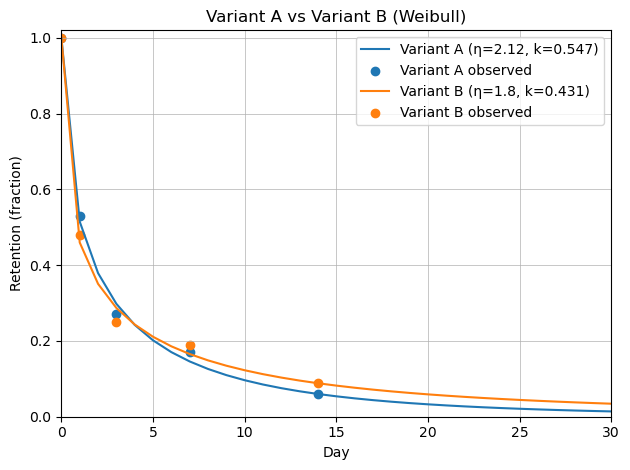

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_weibull_variants(variants, tmax=30, title="Weibull retention curves"):
    days = np.arange(0, tmax + 1, dtype=float)

    plt.figure()

    for name, obs in variants.items():
        # fit Weibull using your existing fit_weibull()
        eta, k = fit_weibull(obs)

        # curve
        y = R_weibull(days, eta, k)
        plt.plot(days, y, label=f"{name} (η={eta:.3g}, k={k:.3g})")

        # observed dots (include D0=100%)
        obs_days = np.array([0] + sorted(int(d) for d in obs.keys() if int(d) != 0), dtype=float)
        obs_ret  = np.array([1.0] + [float(obs[int(d)]) for d in obs_days[1:]], dtype=float)
        if obs_ret.max() > 1.0:
            obs_ret = obs_ret / 100.0
        plt.scatter(obs_days, obs_ret, label=f"{name} observed")

    plt.title(title)
    plt.xlabel("Day")
    plt.ylabel("Retention (fraction)")
    plt.xlim(0, tmax)
    plt.ylim(0, 1.02)
    plt.grid(True, linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- call ---
plot_weibull_variants(variants, tmax=30, title="Variant A vs Variant B (Weibull)")


In [5]:
import numpy as np
import pandas as pd

def simulate_cohorts_one_variant(
    start_date: str,
    horizon_days: int,
    installs_by_day,                 # function(day_index:int)->installs OR array-like length horizon_days+1
    retention_by_age,                # pandas Series or dict: age -> retention (age 0..horizon)
    variant_name: str,
    source_name: str
):
    """
    Returns LONG cohort table with columns:
    event_date, install_date, day, install_day, age, installs, retention, active_users, variant, source
    """
    start = pd.to_datetime(start_date)
    days = np.arange(0, horizon_days + 1, dtype=int)

    # Build calendar days
    event_dates = start + pd.to_timedelta(days, unit="D")
    install_dates = event_dates.copy()

    # Cross join (install_date x event_date), then keep event>=install
    df_i = pd.DataFrame({"install_day": days, "install_date": install_dates})
    df_t = pd.DataFrame({"day": days, "event_date": event_dates})

    cohorts = df_t.merge(df_i, how="cross")
    cohorts = cohorts[cohorts["day"] >= cohorts["install_day"]].copy()

    cohorts["age"] = cohorts["day"] - cohorts["install_day"]

    # installs schedule
    if callable(installs_by_day):
        cohorts["installs"] = cohorts["install_day"].map(installs_by_day).astype(float)
    else:
        inst_arr = np.asarray(installs_by_day, dtype=float)
        cohorts["installs"] = inst_arr[cohorts["install_day"].values]

    # retention lookup by age (cohort-age curve)
    if not isinstance(retention_by_age, pd.Series):
        retention_by_age = pd.Series(retention_by_age)

    cohorts["retention"] = cohorts["age"].map(retention_by_age).fillna(0.0).astype(float)

    # active users contributed by that cohort on that event day
    cohorts["active_users"] = cohorts["installs"] * cohorts["retention"]

    cohorts["variant"] = variant_name
    cohorts["source"] = source_name

    return cohorts


In [7]:
def dau_from_cohort_table(cohorts_long: pd.DataFrame):
    return (cohorts_long
            .groupby(["event_date", "day", "variant"], as_index=False)["active_users"]
            .sum()
            .rename(columns={"active_users": "DAU"}))


In [8]:

tmax = 30  

curves_df2 = pd.DataFrame({
    "day": np.arange(0, tmax + 1, dtype=int),
})

curves_df2["Variant A (New)"] = np.where(
    curves_df2["day"].eq(0),
    1.0,
    0.58 * np.exp(-0.12 * (curves_df2["day"] - 1))
)

curves_df2["Variant B (New)"] = np.where(
    curves_df2["day"].eq(0),
    1.0,
    0.52 * np.exp(-0.10 * (curves_df2["day"] - 1))
)

curves_df2

,day,Variant A (New),Variant B (New)
0,0,1.000000,1.000000
1,1,0.580000,0.520000
2,2,0.514414,0.470515
3,3,0.456244,0.425740
4,4,0.404652,0.385225
5,5,0.358894,0.348566
6,6,0.318311,0.315396
7,7,0.282316,0.285382
8,8,0.250392,0.258224
9,9,0.222078,0.233651


In [9]:
ret_old_A = curves_df.set_index("day")["Variant A"]     # age -> retention
ret_old_B = curves_df.set_index("day")["Variant B"]


In [10]:
ret_new_A = curves_df2.set_index("day")["Variant A (New)"]
ret_new_B = curves_df2.set_index("day")["Variant B (New)"]


In [11]:
def installs_old_sc3(d):
    return 20000 if d < 20 else 12000

def installs_new_sc3(d):
    return 0 if d < 20 else 8000


In [12]:
start_date = "2025-01-01"
horizon_days = 30

# Variant A
coh_A_old = simulate_cohorts_one_variant(start_date, horizon_days, installs_old_sc3, ret_old_A, "A", "old")
coh_A_new = simulate_cohorts_one_variant(start_date, horizon_days, installs_new_sc3, ret_new_A, "A", "new")
coh_A = pd.concat([coh_A_old, coh_A_new], ignore_index=True)

# Variant B
coh_B_old = simulate_cohorts_one_variant(start_date, horizon_days, installs_old_sc3, ret_old_B, "B", "old")
coh_B_new = simulate_cohorts_one_variant(start_date, horizon_days, installs_new_sc3, ret_new_B, "B", "new")
coh_B = pd.concat([coh_B_old, coh_B_new], ignore_index=True)

# Full cohort table for scenario 3 (this has event_date + install_date columns as requested)
cohorts_sc3 = pd.concat([coh_A, coh_B], ignore_index=True)

# DAU by day (optional)
dau_sc3 = dau_from_cohort_table(cohorts_sc3)


In [13]:
installs_20k = lambda d: 20000

cohorts_sc1 = pd.concat([
    simulate_cohorts_one_variant(start_date, horizon_days, installs_20k, ret_old_A, "A", "old"),
    simulate_cohorts_one_variant(start_date, horizon_days, installs_20k, ret_old_B, "B", "old"),
], ignore_index=True)

dau_sc1 = dau_from_cohort_table(cohorts_sc1)


In [14]:
dau_sc1

,event_date,day,variant,DAU
0,2025-01-01,0,A,20000.000000
1,2025-01-01,0,B,20000.000000
2,2025-01-02,1,A,30299.760512
3,2025-01-02,1,B,29197.632790
4,2025-01-03,2,A,37883.649985
...,...,...,...,...
57,2025-01-29,28,B,89941.943774
58,2025-01-30,29,A,80443.065513
59,2025-01-30,29,B,90663.975306
60,2025-01-31,30,A,80723.308697


In [15]:
import numpy as np
import pandas as pd

def compute_daily_kpis_from_dau(
    dau_df,                        # columns: ["event_date","day","variant","DAU"] (DAU can be float)
    purchase_rate_by_variant,      # {"A":0.0305, "B":0.0315} OR {"A": Series indexed by day, "B": Series}
    imp_per_dau_by_variant,        # {"A":2.3, "B":1.6}
    ecpm_by_variant,               # {"A":9.8, "B":10.8}
    scenario_name="sc",
    round_users=True,
    round_impressions=True,
    round_buyers=True,
):
    df = dau_df.copy()
    df["scenario"] = scenario_name

    # 1) round DAU first (as you requested)
    if round_users:
        df["DAU_int"] = df["DAU"].round(0).astype("int64")
    else:
        df["DAU_int"] = df["DAU"].astype(float)

    # helper to get purchase rate per row (supports float or Series by day)
    def _rate(row):
        r = purchase_rate_by_variant[row["variant"]]
        if isinstance(r, (pd.Series, pd.DataFrame)):
            return float(r.loc[row["day"]])
        return float(r)

    # 2) daily ad impressions and buyers based on rounded DAU
    df["imp_per_dau"] = df["variant"].map(imp_per_dau_by_variant).astype(float)
    df["ecpm"] = df["variant"].map(ecpm_by_variant).astype(float)

    df["daily_impressions"] = df["DAU_int"].astype(float) * df["imp_per_dau"]
    if round_impressions:
        df["daily_impressions"] = df["daily_impressions"].round(0).astype("int64")

    df["purchase_rate"] = df.apply(_rate, axis=1)
    df["daily_buyers"] = df["DAU_int"].astype(float) * df["purchase_rate"]
    if round_buyers:
        df["daily_buyers"] = df["daily_buyers"].round(0).astype("int64")

    # 3) ad revenue from impressions (eCPM is $ per 1000 impressions)
    df["daily_ad_rev"] = df["daily_impressions"].astype(float) * (df["ecpm"] / 1000.0)

    # 4) cumulative metrics (within scenario+variant)
    df = df.sort_values(["scenario","variant","day"])
    df["cum_buyers"] = df.groupby(["scenario","variant"])["daily_buyers"].cumsum()
    df["cum_ad_rev"] = df.groupby(["scenario","variant"])["daily_ad_rev"].cumsum()

    # return only the core columns
    return df[[
        "scenario","event_date","day","variant",
        "DAU_int","daily_impressions","daily_buyers","daily_ad_rev",
        "cum_buyers","cum_ad_rev"
    ]].rename(columns={"DAU_int":"daily_users"})


In [16]:
ECPM = {"A": 9.80, "B": 10.80}
IMP_PER_DAU = {"A": 2.3, "B": 1.6}
PURCHASE_RATE = {"A": 0.0305, "B": 0.0315}

kpis_sc3 = compute_daily_kpis_from_dau(
    dau_sc3,                         # event_date, day, variant, DAU
    purchase_rate_by_variant=PURCHASE_RATE,
    imp_per_dau_by_variant=IMP_PER_DAU,
    ecpm_by_variant=ECPM,
    scenario_name="sc3"
)


In [21]:

ECPM = {"A": 9.80, "B": 10.80}
IMP_PER_DAU = {"A": 2.3, "B": 1.6}
BASE_RATE = {"A": 0.0305, "B": 0.0315}

# --- KPI table for Scenario 1 (base purchase rates) ---
kpis_sc1 = compute_daily_kpis_from_dau(
    dau_sc1,                          # event_date, day, variant, DAU
    purchase_rate_by_variant=BASE_RATE,
    imp_per_dau_by_variant=IMP_PER_DAU,
    ecpm_by_variant=ECPM,
    scenario_name="sc1"
)

# --- KPI table for Scenario 2 (same DAU as sc1, but sale rates on days 15–24) ---
days = pd.Index(np.arange(0, 31), name="day")
rate_A_sc2 = pd.Series(0.0305, index=days)
rate_B_sc2 = pd.Series(0.0315, index=days)
rate_A_sc2.loc[15:24] = 0.0405
rate_B_sc2.loc[15:24] = 0.0415

kpis_sc2 = compute_daily_kpis_from_dau(
    dau_sc1,  # reuse sc1 DAU as you said
    purchase_rate_by_variant={"A": rate_A_sc2, "B": rate_B_sc2},
    imp_per_dau_by_variant=IMP_PER_DAU,
    ecpm_by_variant=ECPM,
    scenario_name="sc2"
)


In [24]:
kpis_sc3

,scenario,event_date,day,variant,daily_users,daily_impressions,daily_buyers,daily_ad_rev,cum_buyers,cum_ad_rev
0,sc3,2025-01-01,0,A,20000,46000,610,450.8000,610,450.8000
2,sc3,2025-01-02,1,A,30300,69690,924,682.9620,1534,1133.7620
4,sc3,2025-01-03,2,A,37884,87133,1155,853.9034,2689,1987.6654
6,sc3,2025-01-04,3,A,43844,100841,1337,988.2418,4026,2975.9072
8,sc3,2025-01-05,4,A,48693,111994,1485,1097.5412,5511,4073.4484
...,...,...,...,...,...,...,...,...,...,...
53,sc3,2025-01-27,26,B,94203,150725,2967,1627.8300,57524,31555.7424
55,sc3,2025-01-28,27,B,95961,153538,3023,1658.2104,60547,33213.9528
57,sc3,2025-01-29,28,B,97595,156152,3074,1686.4416,63621,34900.3944
59,sc3,2025-01-30,29,B,99109,158574,3122,1712.5992,66743,36612.9936


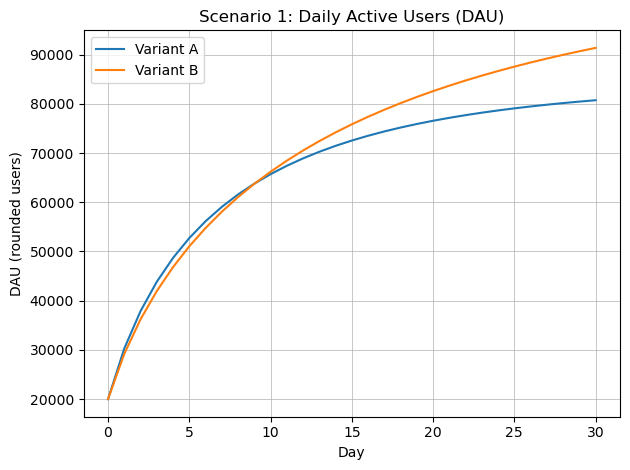

In [25]:
import matplotlib.pyplot as plt

# kpis_sc1 columns assumed:
# ["scenario","event_date","day","variant","daily_users", ...]
g = kpis_sc1.sort_values(["variant", "day"])

plt.figure()
for v, dfv in g.groupby("variant"):
    plt.plot(dfv["day"], dfv["daily_users"], label=f"Variant {v}")

plt.xlabel("Day")
plt.ylabel("DAU (rounded users)")
plt.title("Scenario 1: Daily Active Users (DAU)")
plt.grid(True, linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
kpis_sc1[kpis_sc1["day"]==15]

,scenario,event_date,day,variant,daily_users,daily_impressions,daily_buyers,daily_ad_rev,cum_buyers,cum_ad_rev
30,sc1,2025-01-16,15,A,72533,166826,2212,1634.8948,27151,20066.2546
31,sc1,2025-01-16,15,B,75830,121328,2389,1310.3424,28050,15386.8680


In [37]:
import numpy as np

d = 30
rowA = kpis_sc1[(kpis_sc1["day"] == d) & (kpis_sc1["variant"] == "A")].iloc[0]
rowB = kpis_sc1[(kpis_sc1["day"] == d) & (kpis_sc1["variant"] == "B")].iloc[0]

cum_ad_A = float(rowA["cum_ad_rev"])
cum_ad_B = float(rowB["cum_ad_rev"])
cum_buy_A = float(rowA["cum_buyers"])
cum_buy_B = float(rowB["cum_buyers"])

den = (cum_buy_A - cum_buy_B)
num = (cum_ad_B - cum_ad_A)

v_star = np.nan if den == 0 else num / den
print("Day:", d)
print("CumAdRev A, B:", cum_ad_A, cum_ad_B)
print("CumBuyers A, B:", cum_buy_A, cum_buy_B)
print("v* (avg transaction revenue threshold):", v_star)

# Which side wins?
# Total_B - Total_A = (cum_ad_B - cum_ad_A) + v*(cum_buy_B - cum_buy_A)
# If B has more buyers, B benefits more as v increases; if A has more buyers, A benefits more as v increases.
buyer_diff = cum_buy_B - cum_buy_A

if den == 0:
    print("No flip: CumBuyers are equal. Winner is determined only by CumAdRev (or tie).")
else:
    if buyer_diff > 0:
        # B slope higher -> B wins for v > v*
        print("Rule: B wins if v > v* ; A wins if v < v*")
    else:
        # A slope higher -> A wins for v > v*
        print("Rule: A wins if v > v* ; B wins if v < v*")


Day: 30
CumAdRev A, B: 46366.436200000004 37472.230800000005
CumBuyers A, B: 62741.0 68311.0
v* (avg transaction revenue threshold): 1.596805278276481
Rule: B wins if v > v* ; A wins if v < v*


In [28]:
kpis_sc2[kpis_sc2["day"]==30]

,scenario,event_date,day,variant,daily_users,daily_impressions,daily_buyers,daily_ad_rev,cum_buyers,cum_ad_rev
60,sc2,2025-01-31,30,A,80723,185663,2462,1819.4974,70337,46366.4362
61,sc2,2025-01-31,30,B,91352,146163,2878,1578.5604,76478,37472.2308


In [29]:
import numpy as np

d = 30
rowA = kpis_sc2[(kpis_sc2["day"] == d) & (kpis_sc2["variant"] == "A")].iloc[0]
rowB = kpis_sc2[(kpis_sc2["day"] == d) & (kpis_sc2["variant"] == "B")].iloc[0]

cum_ad_A = float(rowA["cum_ad_rev"])
cum_ad_B = float(rowB["cum_ad_rev"])
cum_buy_A = float(rowA["cum_buyers"])
cum_buy_B = float(rowB["cum_buyers"])

den = (cum_buy_A - cum_buy_B)
num = (cum_ad_B - cum_ad_A)

v_star = np.nan if den == 0 else num / den
print("Day:", d)
print("CumAdRev A, B:", cum_ad_A, cum_ad_B)
print("CumBuyers A, B:", cum_buy_A, cum_buy_B)
print("v* (avg transaction revenue threshold):", v_star)

# Which side wins?
# Total_B - Total_A = (cum_ad_B - cum_ad_A) + v*(cum_buy_B - cum_buy_A)
# If B has more buyers, B benefits more as v increases; if A has more buyers, A benefits more as v increases.
buyer_diff = cum_buy_B - cum_buy_A

if den == 0:
    print("No flip: CumBuyers are equal. Winner is determined only by CumAdRev (or tie).")
else:
    if buyer_diff > 0:
        # B slope higher -> B wins for v > v*
        print("Rule: B wins if v > v* ; A wins if v < v*")
    else:
        # A slope higher -> A wins for v > v*
        print("Rule: A wins if v > v* ; B wins if v < v*")


Day: 30
CumAdRev A, B: 46366.436200000004 37472.230800000005
CumBuyers A, B: 70337.0 76478.0
v* (avg transaction revenue threshold): 1.448331770070021
Rule: B wins if v > v* ; A wins if v < v*


In [30]:
kpis_sc3[kpis_sc3["day"]==30]

,scenario,event_date,day,variant,daily_users,daily_impressions,daily_buyers,daily_ad_rev,cum_buyers,cum_ad_rev
60,sc3,2025-01-31,30,A,91116,209567,2779,2053.7566,64495,47663.6328
61,sc3,2025-01-31,30,B,100506,160810,3166,1736.7480,69909,38349.7416


In [31]:
import numpy as np

d = 30
rowA = kpis_sc3[(kpis_sc3["day"] == d) & (kpis_sc3["variant"] == "A")].iloc[0]
rowB = kpis_sc3[(kpis_sc3["day"] == d) & (kpis_sc3["variant"] == "B")].iloc[0]

cum_ad_A = float(rowA["cum_ad_rev"])
cum_ad_B = float(rowB["cum_ad_rev"])
cum_buy_A = float(rowA["cum_buyers"])
cum_buy_B = float(rowB["cum_buyers"])

den = (cum_buy_A - cum_buy_B)
num = (cum_ad_B - cum_ad_A)

v_star = np.nan if den == 0 else num / den
print("Day:", d)
print("CumAdRev A, B:", cum_ad_A, cum_ad_B)
print("CumBuyers A, B:", cum_buy_A, cum_buy_B)
print("v* (avg transaction revenue threshold):", v_star)

# Which side wins?
# Total_B - Total_A = (cum_ad_B - cum_ad_A) + v*(cum_buy_B - cum_buy_A)
# If B has more buyers, B benefits more as v increases; if A has more buyers, A benefits more as v increases.
buyer_diff = cum_buy_B - cum_buy_A

if den == 0:
    print("No flip: CumBuyers are equal. Winner is determined only by CumAdRev (or tie).")
else:
    if buyer_diff > 0:
        # B slope higher -> B wins for v > v*
        print("Rule: B wins if v > v* ; A wins if v < v*")
    else:
        # A slope higher -> A wins for v > v*
        print("Rule: A wins if v > v* ; B wins if v < v*")


Day: 30
CumAdRev A, B: 47663.63280000001 38349.7416
CumBuyers A, B: 64495.0 69909.0
v* (avg transaction revenue threshold): 1.7203345400812717
Rule: B wins if v > v* ; A wins if v < v*


In [32]:
import numpy as np
import pandas as pd

V = 2.0  # avg transaction revenue per buyer

def timeline_with_total(kpis_df, scenario_label, v=2.0):
    df = kpis_df.copy()

    # keep only A/B rows (we'll add Total)
    df = df[df["variant"].isin(["A", "B"])].copy()

    # add IAP and Total revenue
    df["daily_iap_rev"] = df["daily_buyers"].astype(float) * v
    df["daily_total_rev"] = df["daily_ad_rev"].astype(float) + df["daily_iap_rev"]

    df = df.sort_values(["day", "variant"])
    df["cum_iap_rev"] = df.groupby("variant")["daily_iap_rev"].cumsum()
    df["cum_total_rev"] = df.groupby("variant")["daily_total_rev"].cumsum()

    # build Total = A+B per day
    agg = {
        "daily_users": "sum",
        "daily_impressions": "sum",
        "daily_buyers": "sum",
        "daily_ad_rev": "sum",
        "daily_iap_rev": "sum",
        "daily_total_rev": "sum",
    }
    if "event_date" in df.columns:
        total = df.groupby(["day", "event_date"], as_index=False).agg(agg)
    else:
        total = df.groupby(["day"], as_index=False).agg(agg)

    total["variant"] = "Total"
    total = total.sort_values("day")
    total["cum_iap_rev"] = total["daily_iap_rev"].cumsum()
    total["cum_total_rev"] = total["daily_total_rev"].cumsum()

    # attach scenario label
    df["scenario"] = scenario_label
    total["scenario"] = scenario_label

    # final
    out = pd.concat([df, total], ignore_index=True)
    cols = ["scenario"]
    if "event_date" in out.columns:
        cols += ["event_date"]
    cols += [
        "day", "variant",
        "daily_users", "daily_impressions", "daily_buyers",
        "daily_ad_rev", "daily_iap_rev", "daily_total_rev",
        "cum_total_rev"
    ]
    return out[cols].sort_values(["scenario", "variant", "day"]).reset_index(drop=True)

timeline_sc2 = timeline_with_total(kpis_sc2, "sc2", v=V)
timeline_sc3 = timeline_with_total(kpis_sc3, "sc3", v=V)

timeline_both = pd.concat([timeline_sc2, timeline_sc3], ignore_index=True)
timeline_both


,scenario,event_date,day,variant,daily_users,daily_impressions,daily_buyers,daily_ad_rev,daily_iap_rev,daily_total_rev,cum_total_rev
0,sc2,2025-01-01,0,A,20000,46000,610,450.8000,1220.0,1670.8000,1670.8000
1,sc2,2025-01-02,1,A,30300,69690,924,682.9620,1848.0,2530.9620,4201.7620
2,sc2,2025-01-03,2,A,37884,87133,1155,853.9034,2310.0,3163.9034,7365.6654
3,sc2,2025-01-04,3,A,43844,100841,1337,988.2418,2674.0,3662.2418,11027.9072
4,sc2,2025-01-05,4,A,48693,111994,1485,1097.5412,2970.0,4067.5412,15095.4484
...,...,...,...,...,...,...,...,...,...,...,...
181,sc3,2025-01-27,26,Total,180264,348665,5592,3567.6420,11184.0,14751.6420,293393.6486
182,sc3,2025-01-28,27,Total,183469,354806,5692,3630.6368,11384.0,15014.6368,308408.2854
183,sc3,2025-01-29,28,Total,186426,360463,5783,3688.6894,11566.0,15254.6894,323662.9748
184,sc3,2025-01-30,29,Total,189140,365645,5868,3741.8950,11736.0,15477.8950,339140.8698


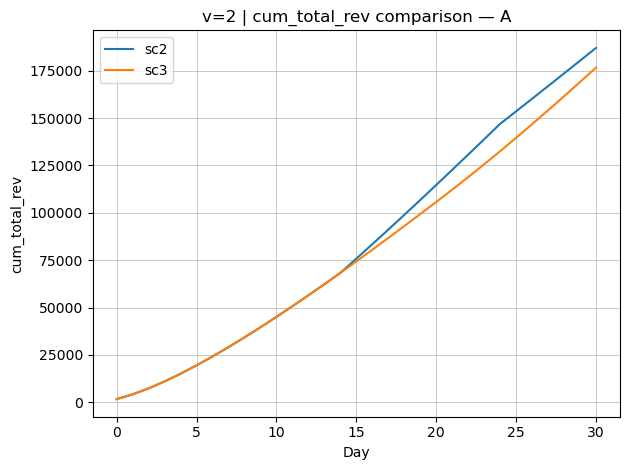

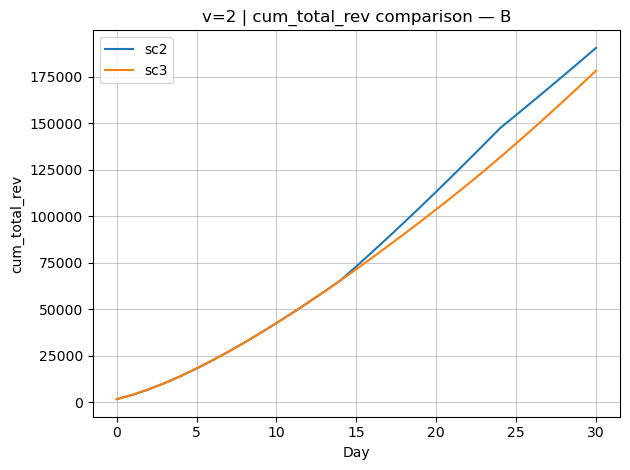

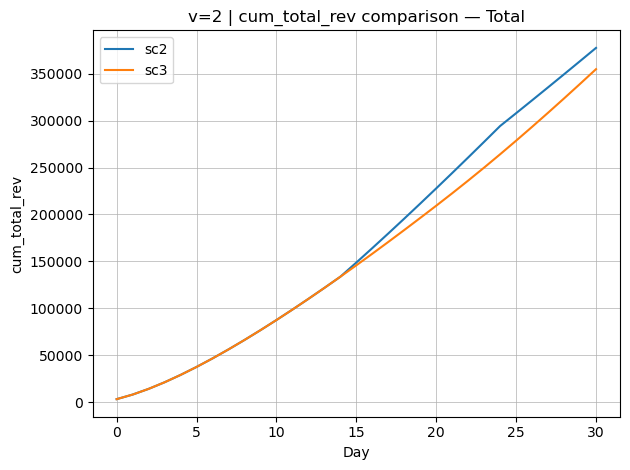

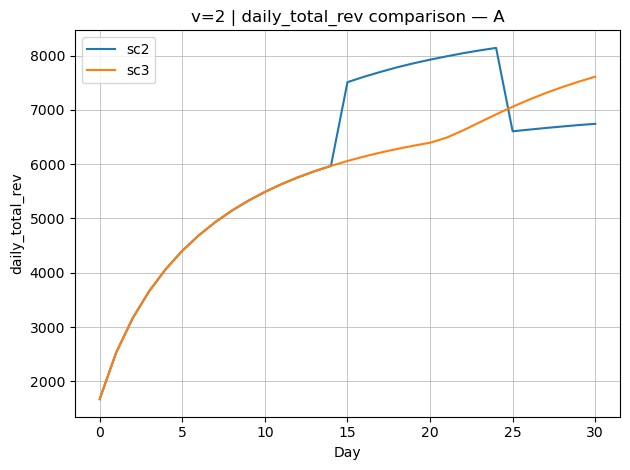

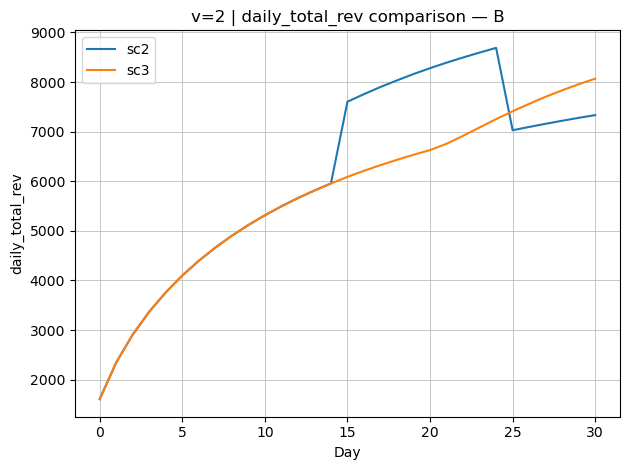

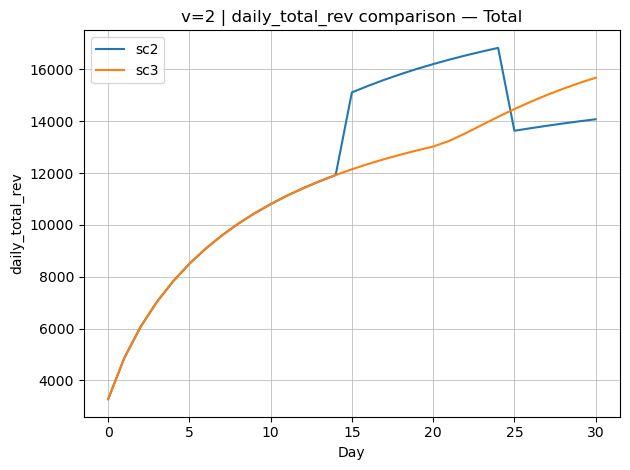

In [34]:
import matplotlib.pyplot as plt

# timeline_both must have: scenario (sc2/sc3), day, variant (A/B/Total), cum_total_rev (and/or daily_total_rev)

def plot_compare_scenarios(timeline_both, value_col="cum_total_rev", title_prefix=""):
    variants = ["A", "B", "Total"]

    for v in variants:
        df = timeline_both[timeline_both["variant"] == v].sort_values(["scenario", "day"])

        plt.figure()
        for sc, g in df.groupby("scenario"):
            plt.plot(g["day"], g[value_col], label=sc)

        plt.xlabel("Day")
        plt.ylabel(value_col)
        plt.title(f"{title_prefix}{value_col} comparison — {v}")
        plt.grid(True, linewidth=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Cumulative total revenue (ads + v*buyers)
plot_compare_scenarios(timeline_both, value_col="cum_total_rev", title_prefix="v=2 | ")

# If you also want daily total revenue:
plot_compare_scenarios(timeline_both, value_col="daily_total_rev", title_prefix="v=2 | ")


In [35]:
import numpy as np
import pandas as pd

V = 5.0  # avg transaction revenue per buyer

def timeline_with_total(kpis_df, scenario_label, v=2.0):
    df = kpis_df.copy()

    # keep only A/B rows (we'll add Total)
    df = df[df["variant"].isin(["A", "B"])].copy()

    # add IAP and Total revenue
    df["daily_iap_rev"] = df["daily_buyers"].astype(float) * v
    df["daily_total_rev"] = df["daily_ad_rev"].astype(float) + df["daily_iap_rev"]

    df = df.sort_values(["day", "variant"])
    df["cum_iap_rev"] = df.groupby("variant")["daily_iap_rev"].cumsum()
    df["cum_total_rev"] = df.groupby("variant")["daily_total_rev"].cumsum()

    # build Total = A+B per day
    agg = {
        "daily_users": "sum",
        "daily_impressions": "sum",
        "daily_buyers": "sum",
        "daily_ad_rev": "sum",
        "daily_iap_rev": "sum",
        "daily_total_rev": "sum",
    }
    if "event_date" in df.columns:
        total = df.groupby(["day", "event_date"], as_index=False).agg(agg)
    else:
        total = df.groupby(["day"], as_index=False).agg(agg)

    total["variant"] = "Total"
    total = total.sort_values("day")
    total["cum_iap_rev"] = total["daily_iap_rev"].cumsum()
    total["cum_total_rev"] = total["daily_total_rev"].cumsum()

    # attach scenario label
    df["scenario"] = scenario_label
    total["scenario"] = scenario_label

    # final
    out = pd.concat([df, total], ignore_index=True)
    cols = ["scenario"]
    if "event_date" in out.columns:
        cols += ["event_date"]
    cols += [
        "day", "variant",
        "daily_users", "daily_impressions", "daily_buyers",
        "daily_ad_rev", "daily_iap_rev", "daily_total_rev",
        "cum_total_rev"
    ]
    return out[cols].sort_values(["scenario", "variant", "day"]).reset_index(drop=True)

timeline_sc2 = timeline_with_total(kpis_sc2, "sc2", v=V)
timeline_sc3 = timeline_with_total(kpis_sc3, "sc3", v=V)

timeline_both = pd.concat([timeline_sc2, timeline_sc3], ignore_index=True)
timeline_both


,scenario,event_date,day,variant,daily_users,daily_impressions,daily_buyers,daily_ad_rev,daily_iap_rev,daily_total_rev,cum_total_rev
0,sc2,2025-01-01,0,A,20000,46000,610,450.8000,3050.0,3500.8000,3500.8000
1,sc2,2025-01-02,1,A,30300,69690,924,682.9620,4620.0,5302.9620,8803.7620
2,sc2,2025-01-03,2,A,37884,87133,1155,853.9034,5775.0,6628.9034,15432.6654
3,sc2,2025-01-04,3,A,43844,100841,1337,988.2418,6685.0,7673.2418,23105.9072
4,sc2,2025-01-05,4,A,48693,111994,1485,1097.5412,7425.0,8522.5412,31628.4484
...,...,...,...,...,...,...,...,...,...,...,...
181,sc3,2025-01-27,26,Total,180264,348665,5592,3567.6420,27960.0,31527.6420,626741.6486
182,sc3,2025-01-28,27,Total,183469,354806,5692,3630.6368,28460.0,32090.6368,658832.2854
183,sc3,2025-01-29,28,Total,186426,360463,5783,3688.6894,28915.0,32603.6894,691435.9748
184,sc3,2025-01-30,29,Total,189140,365645,5868,3741.8950,29340.0,33081.8950,724517.8698


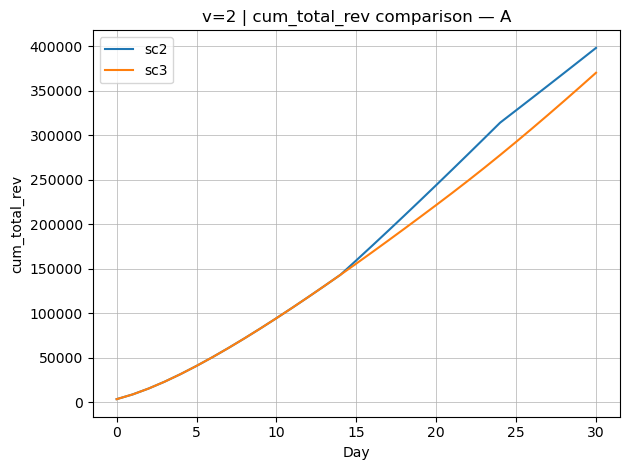

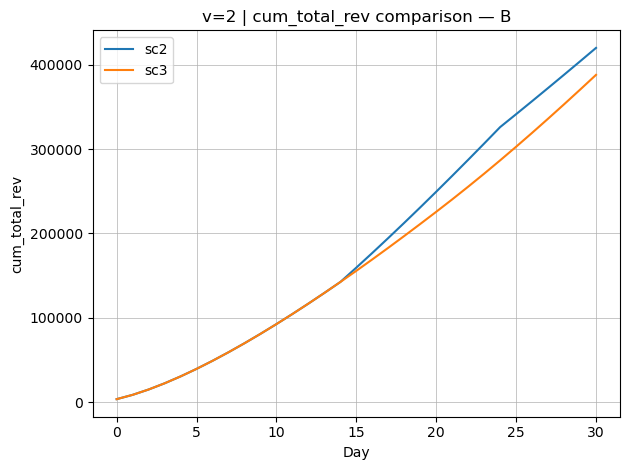

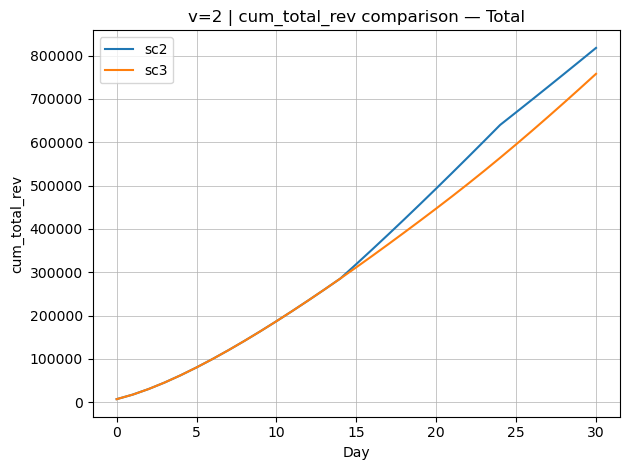

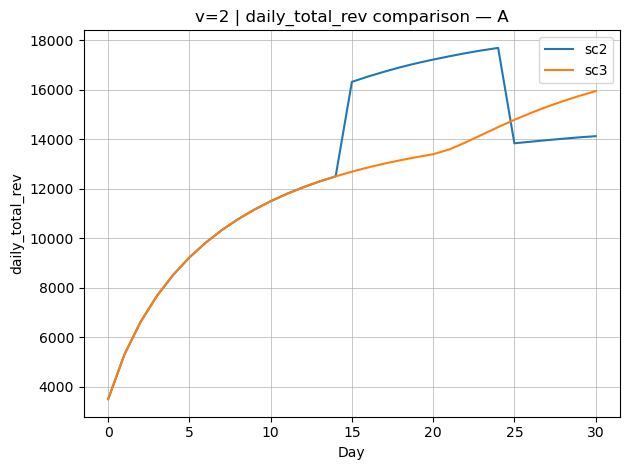

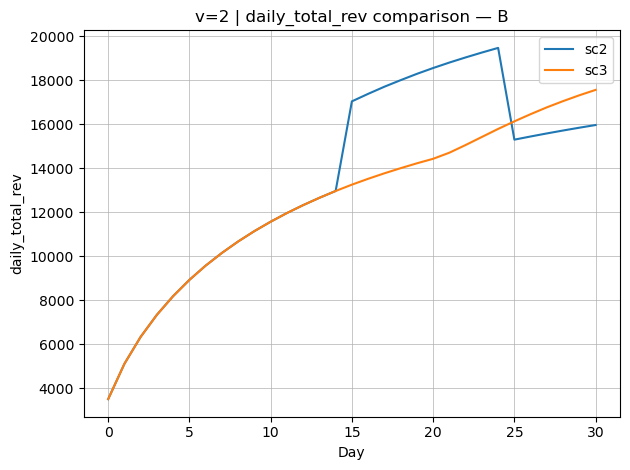

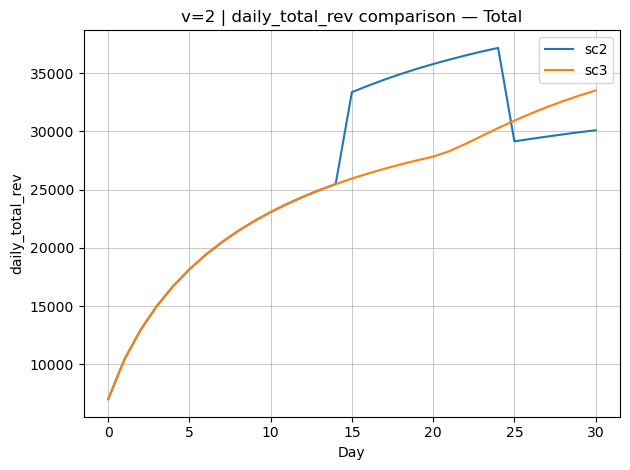

In [36]:
import matplotlib.pyplot as plt

# timeline_both must have: scenario (sc2/sc3), day, variant (A/B/Total), cum_total_rev (and/or daily_total_rev)

def plot_compare_scenarios(timeline_both, value_col="cum_total_rev", title_prefix=""):
    variants = ["A", "B", "Total"]

    for v in variants:
        df = timeline_both[timeline_both["variant"] == v].sort_values(["scenario", "day"])

        plt.figure()
        for sc, g in df.groupby("scenario"):
            plt.plot(g["day"], g[value_col], label=sc)

        plt.xlabel("Day")
        plt.ylabel(value_col)
        plt.title(f"{title_prefix}{value_col} comparison — {v}")
        plt.grid(True, linewidth=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Cumulative total revenue (ads + v*buyers)
plot_compare_scenarios(timeline_both, value_col="cum_total_rev", title_prefix="v=2 | ")

# If you also want daily total revenue:
plot_compare_scenarios(timeline_both, value_col="daily_total_rev", title_prefix="v=2 | ")
